### Regression Language Model (RLM)

In [13]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from collections import Counter
import re

import warnings
warnings.filterwarnings("ignore", category=UserWarning)


In [14]:
torch.manual_seed(42)
np.random.seed(42)

In [15]:
def generate_synthetic_data(n_samples=2000):
    """Generate synthetic text-to-number regression data"""

    templates = [
        ("The temperature is {} degrees", lambda x: x),
        ("I rate this {} out of ten", lambda x: x),
        ("The price is {} dollars", lambda x: x),
        ("Confidence level: {}", lambda x: x / 100),
        ("Speed of {} kilometers per hour", lambda x: x / 10),
        ("{} percent complete", lambda x: x / 100),
        ("Scored {} points in the game", lambda x: x / 10),
        ("The distance is {} meters", lambda x: x),
    ]

    data = []
    for _ in range(n_samples):
        template, transform = templates[np.random.randint(len(templates))]
        value = np.random.uniform(0, 100)
        text = template.format(round(value, 1))
        target = transform(value)
        data.append((text, target))

    return data

In [16]:
class SimpleTokenizer:
    def __init__(self):
        self.word2idx = {"": 0, "": 1}
        self.idx2word = {0: "", 1: ""}
        self.vocab_size = 2

    def fit(self, texts):
        """Build vocabulary from texts"""
        words = []
        for text in texts:
            words.extend(re.findall(r'\w+|[^\w\s]', text.lower()))

        word_counts = Counter(words)
        for word, _ in word_counts.most_common():
            if word not in self.word2idx:
                self.word2idx[word] = self.vocab_size
                self.idx2word[self.vocab_size] = word
                self.vocab_size += 1

    def encode(self, text, max_len=20):
        """Convert text to token indices"""
        words = re.findall(r'\w+|[^\w\s]', text.lower())
        indices = [self.word2idx.get(w, 1) for w in words]

        if len(indices) < max_len:
            indices += [0] * (max_len - len(indices))
        else:
            indices = indices[:max_len]

        return indices

In [17]:
class RLMDataset(Dataset):
    def __init__(self, data, tokenizer, max_len=20):
        self.data = data
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        text, target = self.data[idx]
        tokens = self.tokenizer.encode(text, self.max_len)
        return torch.tensor(tokens), torch.tensor([target], dtype=torch.float32)

class RegressionLanguageModel(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, num_heads=4, num_layers=2,
                 dropout=0.1, max_len=20):
        super().__init__()

        self.token_embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.position_embedding = nn.Embedding(max_len, embed_dim)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=embed_dim * 4,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.fc1 = nn.Linear(embed_dim, 64)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(64, 1)

        self.max_len = max_len

    def forward(self, x):
        batch_size, seq_len = x.shape

        positions = torch.arange(0, seq_len, device=x.device).unsqueeze(0).expand(batch_size, -1)

        token_embed = self.token_embedding(x)
        pos_embed = self.position_embedding(positions)
        embeddings = token_embed + pos_embed

        padding_mask = (x == 0)

        encoded = self.transformer(embeddings, src_key_padding_mask=padding_mask)

        mask_expanded = (~padding_mask).unsqueeze(-1).float()
        summed = (encoded * mask_expanded).sum(dim=1)
        pooled = summed / mask_expanded.sum(dim=1)

        x = self.fc1(pooled)
        x = self.relu(x)
        x = self.dropout(x)
        output = self.fc2(x)

        return output

In [ ]:
def train_rlm(model, train_loader, val_loader, epochs=30, lr=0.001):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)

    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses, val_losses = [], []

    print(f"\n Training on {device}")
    print("-" * 60)

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for tokens, targets in train_loader:
            tokens, targets = tokens.to(device), targets.to(device)

            optimizer.zero_grad()
            outputs = model(tokens)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        train_loss /= len(train_loader)
        train_losses.append(train_loss)

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for tokens, targets in val_loader:
                tokens, targets = tokens.to(device), targets.to(device)
                outputs = model(tokens)
                loss = criterion(outputs, targets)
                val_loss += loss.item()

        val_loss /= len(val_loader)
        val_losses.append(val_loss)

        print(f"Epoch {epoch+1:2d}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    return train_losses, val_losses


📝 Generating synthetic data...
Train samples: 1600, Val samples: 400

🔤 Building tokenizer...
Vocabulary size: 130

 Building Regression Language Model...
Model parameters: 424,065

📊 Training on cuda
------------------------------------------------------------
Epoch  1/30 | Train Loss: 1257.0407 | Val Loss: 974.0351
Epoch  2/30 | Train Loss: 678.2476 | Val Loss: 396.9734
Epoch  3/30 | Train Loss: 423.6459 | Val Loss: 397.8059
Epoch  4/30 | Train Loss: 421.6971 | Val Loss: 396.2923
Epoch  5/30 | Train Loss: 420.8439 | Val Loss: 397.3943
Epoch  6/30 | Train Loss: 431.9573 | Val Loss: 395.4629
Epoch  7/30 | Train Loss: 424.9870 | Val Loss: 398.6235
Epoch  8/30 | Train Loss: 421.6133 | Val Loss: 394.3797
Epoch  9/30 | Train Loss: 424.9317 | Val Loss: 397.5491
Epoch 10/30 | Train Loss: 420.3340 | Val Loss: 396.4126
Epoch 11/30 | Train Loss: 424.4388 | Val Loss: 394.0912
Epoch 12/30 | Train Loss: 432.7981 | Val Loss: 393.2730
Epoch 13/30 | Train Loss: 420.4540 | Val Loss: 393.9044
Epoch 14

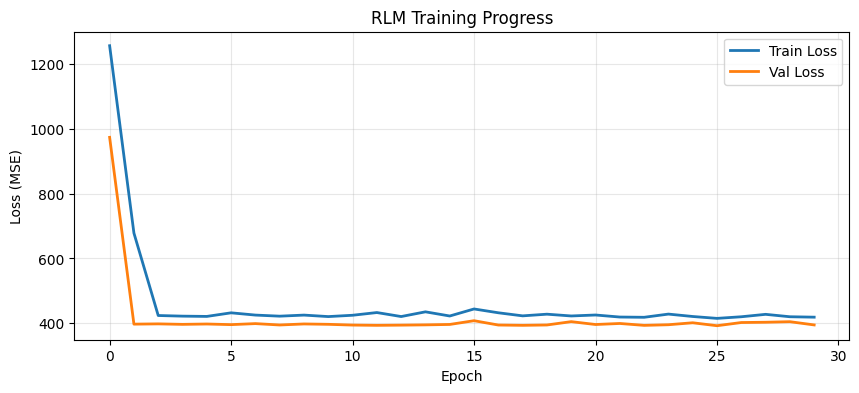


 Testing Predictions:
------------------------------------------------------------
Input: The temperature is 25.5 degrees
Predicted value: 51.4684

Input: I rate this 8.0 out of ten
Predicted value: 51.4682

Input: The price is 45.0 dollars
Predicted value: 51.4685

Input: 75.0 percent complete
Predicted value: 0.7430

Done


In [19]:
print("\n Generating synthetic data...")
data = generate_synthetic_data(2000)
split_idx = int(0.8 * len(data))
train_data, val_data = data[:split_idx], data[split_idx:]
print(f"Train samples: {len(train_data)}, Val samples: {len(val_data)}")

print("\n Building tokenizer...")
tokenizer = SimpleTokenizer()
tokenizer.fit([text for text, _ in train_data])
print(f"Vocabulary size: {tokenizer.vocab_size}")

train_dataset = RLMDataset(train_data, tokenizer)
val_dataset = RLMDataset(val_data, tokenizer)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

print("\n Building Regression Language Model...")
model = RegressionLanguageModel(vocab_size=tokenizer.vocab_size)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

train_losses, val_losses = train_rlm(model, train_loader, val_loader)

plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train Loss', linewidth=2)
plt.plot(val_losses, label='Val Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('RLM Training Progress')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\n Testing Predictions:")
print("-" * 60)
test_examples = [
    "The temperature is 25.5 degrees",
    "I rate this 8.0 out of ten",
    "The price is 45.0 dollars",
    "75.0 percent complete"
]

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.eval()
with torch.no_grad():
    for text in test_examples:
        tokens = torch.tensor([tokenizer.encode(text)]).to(device)
        prediction = model(tokens).item()
        print(f"Input: {text}")
        print(f"Predicted value: {prediction:.4f}\n")

print("Done")